**Task 1: Custom CNNs and Shortcut Learning**

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [7]:
class TinyCNN(nn.Module):
    """
    Conv1: in_ch→8,  3×3 pad=1  → MaxPool → 8×14×14
    Conv2: 8→16,     3×3 pad=1  → MaxPool → 16×7×7
    Conv3: 16→16,    3×3 pad=1  → MaxPool → 16×3×3
    FC1:  144→64   FC2: 64→10
    ~19k params for in_channels=1, ~20k for in_channels=3
    """
    def __init__(self, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1),          nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 16, 3, padding=1),         nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 3 * 3, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [8]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        n          += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss   = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        n          += x.size(0)
    return total_loss / n, correct / n


def run_training(model, train_loader, val_loader, epochs=15, lr=1e-3, label=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
    history   = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    for ep in range(1, epochs+1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
        vl, va = evaluate(model, val_loader, criterion)
        scheduler.step()
        history["train_loss"].append(tl);  history["val_loss"].append(vl)
        history["train_acc"].append(ta);   history["val_acc"].append(va)
        print(f"[{label}] Ep {ep:02d}/{epochs} | "
              f"Train loss {tl:.4f} acc {ta:.4f} | "
              f"Val loss {vl:.4f} acc {va:.4f}")
    return history


def plot_curves(hist, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(hist["train_loss"])+1)
    ax1.plot(ep, hist["train_loss"], label="Train")
    ax1.plot(ep, hist["val_loss"],   label="Val")
    ax1.set_title(f"{title} — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
    ax2.plot(ep, hist["train_acc"],  label="Train")
    ax2.plot(ep, hist["val_acc"],    label="Val")
    ax2.set_title(f"{title} — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout(); plt.show()


def plot_filters(model, title="Conv1 filters"):
    w = model.features[0].weight.data.cpu()   # (8, in_ch, 3, 3)
    # use only first channel for display
    fig, axes = plt.subplots(2, 4, figsize=(8, 4))
    fig.suptitle(title)
    for i, ax in enumerate(axes.flat):
        f    = w[i, 0]
        vmax = f.abs().max().item()
        ax.imshow(f.numpy(), cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(f"Filter {i+1}"); ax.axis("off")
    plt.tight_layout(); plt.show()


def show_samples(dataset, n=8, title=""):
    imgs = torch.stack([dataset[i][0] for i in range(n)])
    imgs = (imgs * 0.5 + 0.5).clamp(0, 1)
    fig, axes = plt.subplots(1, n, figsize=(12, 2))
    fig.suptitle(title)
    for ax, img in zip(axes, imgs):
        ax.imshow(img.permute(1, 2, 0).numpy()); ax.axis("off")
    plt.tight_layout(); plt.show()

In [9]:
BATCH    = 128
VAL_FRAC = 0.1

tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST(root="./data", train=True,  download=True, transform=tf)
test_ds    = datasets.MNIST(root="./data", train=False, download=True, transform=tf)

n_val   = int(len(full_train) * VAL_FRAC)
n_train = len(full_train) - n_val
train_ds, val_ds = random_split(full_train, [n_train, n_val],
                                generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"MNIST — Train: {n_train} | Val: {n_val} | Test: {len(test_ds)}")

# Build model and verify parameter count
model_a      = TinyCNN(in_channels=1).to(DEVICE)
total_params = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}  (limit: 50,000)")
assert total_params <= 50_000, "Parameter budget exceeded!"

# Train
hist_a = run_training(model_a, train_loader, val_loader, epochs=15, label="MNIST")

# Test accuracy
crit = nn.CrossEntropyLoss()
_, test_acc_a = evaluate(model_a, test_loader, crit)
print(f"\nPart A — Test Accuracy: {test_acc_a*100:.2f}%")

torch.save(model_a.state_dict(), "model_a_mnist.pth")
print("Saved: model_a_mnist.pth")
# Note: curves are plotted and saved in Cell 5

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.0MB/s]


MNIST — Train: 54000 | Val: 6000 | Test: 10000
Trainable parameters: 13,498  (limit: 50,000)
[MNIST] Ep 01/15 | Train loss 0.5068 acc 0.8406 | Val loss 0.1188 acc 0.9647
[MNIST] Ep 02/15 | Train loss 0.1469 acc 0.9551 | Val loss 0.0901 acc 0.9725
[MNIST] Ep 03/15 | Train loss 0.1102 acc 0.9660 | Val loss 0.0791 acc 0.9763
[MNIST] Ep 04/15 | Train loss 0.0923 acc 0.9723 | Val loss 0.0725 acc 0.9775
[MNIST] Ep 05/15 | Train loss 0.0786 acc 0.9757 | Val loss 0.0612 acc 0.9817
[MNIST] Ep 06/15 | Train loss 0.0726 acc 0.9777 | Val loss 0.0585 acc 0.9832
[MNIST] Ep 07/15 | Train loss 0.0642 acc 0.9798 | Val loss 0.0521 acc 0.9845
[MNIST] Ep 08/15 | Train loss 0.0534 acc 0.9834 | Val loss 0.0479 acc 0.9865
[MNIST] Ep 09/15 | Train loss 0.0497 acc 0.9849 | Val loss 0.0463 acc 0.9870
[MNIST] Ep 10/15 | Train loss 0.0472 acc 0.9852 | Val loss 0.0519 acc 0.9848
[MNIST] Ep 11/15 | Train loss 0.0467 acc 0.9857 | Val loss 0.0441 acc 0.9863
[MNIST] Ep 12/15 | Train loss 0.0432 acc 0.9868 | Val loss 0

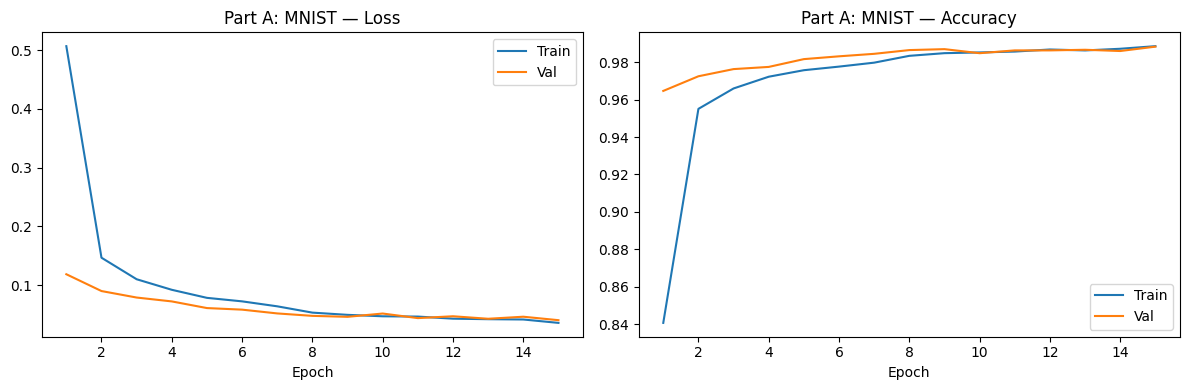

Saved: mnist_curves.png
Analytical 1.1 — Final train/val accuracy gap: 0.03%
(< 2% → good generalisation | 2–5% → mild overfit | >5% → overfit)


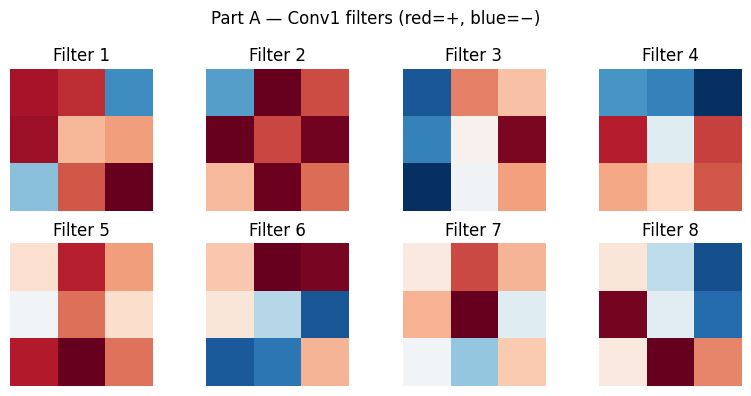

Saved: mnist_filters.png


In [10]:
# Loss & accuracy curves
def plot_curves_save(hist, title, fname):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(hist["train_loss"])+1)
    ax1.plot(ep, hist["train_loss"], label="Train")
    ax1.plot(ep, hist["val_loss"],   label="Val")
    ax1.set_title(f"{title} — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
    ax2.plot(ep, hist["train_acc"],  label="Train")
    ax2.plot(ep, hist["val_acc"],    label="Val")
    ax2.set_title(f"{title} — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

plot_curves_save(hist_a, "Part A: MNIST", "mnist_curves.png")

# Analytical 1.1 — overfit/underfit check
gap = abs(hist_a["train_acc"][-1] - hist_a["val_acc"][-1])
print(f"Analytical 1.1 — Final train/val accuracy gap: {gap*100:.2f}%")
print("(< 2% → good generalisation | 2–5% → mild overfit | >5% → overfit)")

# Analytical 1.2 — Conv1 filter visualisation
def plot_filters_save(model, title, fname):
    w = model.features[0].weight.data.cpu()
    fig, axes = plt.subplots(2, 4, figsize=(8, 4))
    fig.suptitle(title)
    for i, ax in enumerate(axes.flat):
        f    = w[i, 0]
        vmax = f.abs().max().item()
        ax.imshow(f.numpy(), cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(f"Filter {i+1}"); ax.axis("off")
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

plot_filters_save(model_a, "Part A — Conv1 filters (red=+, blue=−)", "mnist_filters.png")

C-MNIST — Train: 54000 | Val: 6000 | Test biased: 10000 | Test unbiased: 10000


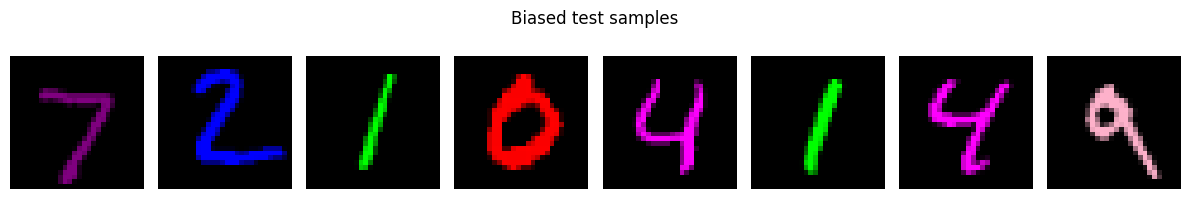

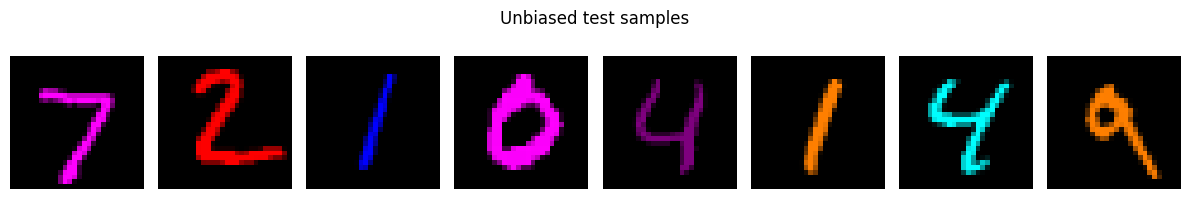

In [11]:
DRIVE_PATH = "/content/drive/MyDrive/Data"

def load_pt(fname):
    imgs, labels = torch.load(os.path.join(DRIVE_PATH, fname), weights_only=False)
    imgs   = imgs.float() / 255.0 if imgs.dtype == torch.uint8 else imgs.float()
    imgs   = (imgs - 0.5) / 0.5   # normalise to [-1, 1]
    labels = labels.long()
    return TensorDataset(imgs, labels)

full_b  = load_pt("train_biased.pt")
test_b  = load_pt("test_biased.pt")
test_ub = load_pt("test_unbiased.pt")

n_v = int(len(full_b) * VAL_FRAC)
n_t = len(full_b) - n_v
train_b, val_b = random_split(full_b, [n_t, n_v],
                               generator=torch.Generator().manual_seed(SEED))

tr_b_loader   = DataLoader(train_b, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
va_b_loader   = DataLoader(val_b,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
tst_b_loader  = DataLoader(test_b,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
tst_ub_loader = DataLoader(test_ub, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"C-MNIST — Train: {n_t} | Val: {n_v} | "
      f"Test biased: {len(test_b)} | Test unbiased: {len(test_ub)}")

# Preview samples
show_samples(test_b,  title="Biased test samples")
show_samples(test_ub, title="Unbiased test samples")

Part B model params: 13,642
[C-MNIST] Ep 01/15 | Train loss 0.6545 acc 0.8216 | Val loss 0.2362 acc 0.9483
[C-MNIST] Ep 02/15 | Train loss 0.2299 acc 0.9485 | Val loss 0.1675 acc 0.9583
[C-MNIST] Ep 03/15 | Train loss 0.1706 acc 0.9579 | Val loss 0.1200 acc 0.9665
[C-MNIST] Ep 04/15 | Train loss 0.1351 acc 0.9637 | Val loss 0.1037 acc 0.9693
[C-MNIST] Ep 05/15 | Train loss 0.1087 acc 0.9708 | Val loss 0.0887 acc 0.9753
[C-MNIST] Ep 06/15 | Train loss 0.0911 acc 0.9744 | Val loss 0.0679 acc 0.9787
[C-MNIST] Ep 07/15 | Train loss 0.0778 acc 0.9771 | Val loss 0.0705 acc 0.9798
[C-MNIST] Ep 08/15 | Train loss 0.0618 acc 0.9821 | Val loss 0.0535 acc 0.9843
[C-MNIST] Ep 09/15 | Train loss 0.0568 acc 0.9835 | Val loss 0.0523 acc 0.9848
[C-MNIST] Ep 10/15 | Train loss 0.0548 acc 0.9835 | Val loss 0.0504 acc 0.9855
[C-MNIST] Ep 11/15 | Train loss 0.0500 acc 0.9846 | Val loss 0.0435 acc 0.9878
[C-MNIST] Ep 12/15 | Train loss 0.0471 acc 0.9859 | Val loss 0.0473 acc 0.9862
[C-MNIST] Ep 13/15 | Tra

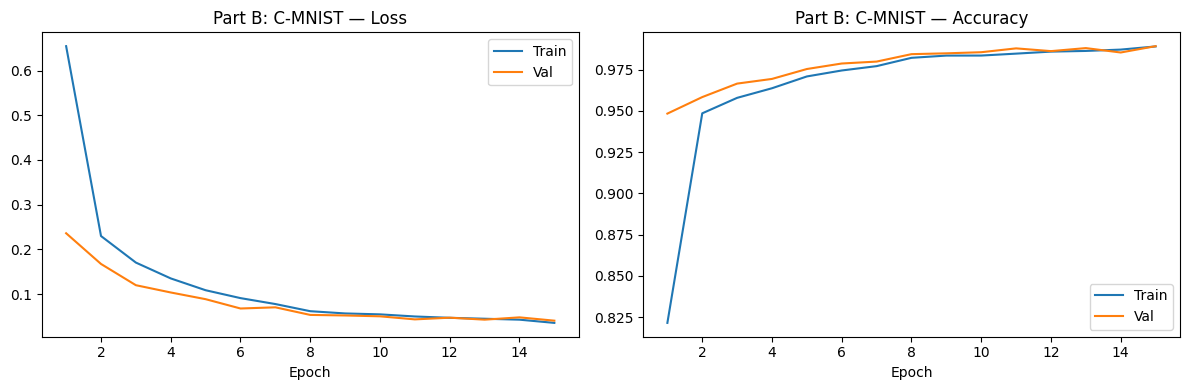


Analytical 1.3:
  Biased   test accuracy : 99.14%
  Unbiased test accuracy : 86.15%
  Accuracy drop          : 12.99%

Saved: model_b_cmnist.pth


In [12]:
model_b  = TinyCNN(in_channels=3).to(DEVICE)
params_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print(f"Part B model params: {params_b:,}")

hist_b = run_training(model_b, tr_b_loader, va_b_loader, epochs=15, label="C-MNIST")

# Loss & accuracy curves
def plot_curves(hist, title, fname=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(hist["train_loss"])+1)
    ax1.plot(ep, hist["train_loss"], label="Train")
    ax1.plot(ep, hist["val_loss"],   label="Val")
    ax1.set_title(f"{title} — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
    ax2.plot(ep, hist["train_acc"],  label="Train")
    ax2.plot(ep, hist["val_acc"],    label="Val")
    ax2.set_title(f"{title} — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")
    plt.show()

plot_curves(hist_b, "Part B: C-MNIST", "cmnist_curves.png")

# Analytical 1.3 — biased vs unbiased accuracy
crit = nn.CrossEntropyLoss()
_, acc_biased   = evaluate(model_b, tst_b_loader,  crit)
_, acc_unbiased = evaluate(model_b, tst_ub_loader, crit)

print(f"\nAnalytical 1.3:")
print(f"  Biased   test accuracy : {acc_biased*100:.2f}%")
print(f"  Unbiased test accuracy : {acc_unbiased*100:.2f}%")
print(f"  Accuracy drop          : {(acc_biased - acc_unbiased)*100:.2f}%")

torch.save(model_b.state_dict(), "model_b_cmnist.pth")
print("\nSaved: model_b_cmnist.pth")

**Task 2: Transfer Learning and Interpretability**

In [13]:
# Install GradCAM library
!pip install grad-cam -q

from google.colab import drive
drive.mount('/content/drive')

import os, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

STL10_CLASSES = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [14]:
del train_loader, test_loader

In [15]:
BATCH = 64

# ResNet-18 expects 224×224 ImageNet-normalised images
tf_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

tf_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

train_ds = datasets.STL10(root="./data", split="train", download=True, transform=tf_train)
test_ds  = datasets.STL10(root="./data", split="test",  download=True, transform=tf_test)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"STL-10 — Train: {len(train_ds)} | Test: {len(test_ds)}")

STL-10 — Train: 5000 | Test: 8000


In [16]:
# Load pre-trained ResNet-18
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all layers (backbone)
for param in model.parameters():
    param.requires_grad = False

# Replace final FC layer with new 10-class head (unfrozen by default)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 10)

model = model.to(DEVICE)

# Verify: only the new head should have requires_grad=True
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,}  (head only)")
print(f"Total params     : {total:,}  (backbone frozen)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]

Trainable params : 5,130  (head only)
Total params     : 11,181,642  (backbone frozen)


Ep 01/15 | Train loss 0.8948 acc 0.7744 | Test loss 0.3652 acc 0.9229
Ep 02/15 | Train loss 0.3116 acc 0.9268 | Test loss 0.2546 acc 0.9336
Ep 03/15 | Train loss 0.2376 acc 0.9390 | Test loss 0.2136 acc 0.9403
Ep 04/15 | Train loss 0.1979 acc 0.9446 | Test loss 0.1975 acc 0.9399
Ep 05/15 | Train loss 0.1784 acc 0.9496 | Test loss 0.1834 acc 0.9455
Ep 06/15 | Train loss 0.1610 acc 0.9522 | Test loss 0.1745 acc 0.9461
Ep 07/15 | Train loss 0.1555 acc 0.9552 | Test loss 0.1729 acc 0.9439
Ep 08/15 | Train loss 0.1373 acc 0.9618 | Test loss 0.1648 acc 0.9461
Ep 09/15 | Train loss 0.1348 acc 0.9600 | Test loss 0.1663 acc 0.9455
Ep 10/15 | Train loss 0.1354 acc 0.9602 | Test loss 0.1600 acc 0.9456
Ep 11/15 | Train loss 0.1299 acc 0.9628 | Test loss 0.1612 acc 0.9457
Ep 12/15 | Train loss 0.1312 acc 0.9604 | Test loss 0.1624 acc 0.9455
Ep 13/15 | Train loss 0.1222 acc 0.9656 | Test loss 0.1554 acc 0.9475
Ep 14/15 | Train loss 0.1130 acc 0.9674 | Test loss 0.1603 acc 0.9453
Ep 15/15 | Train los

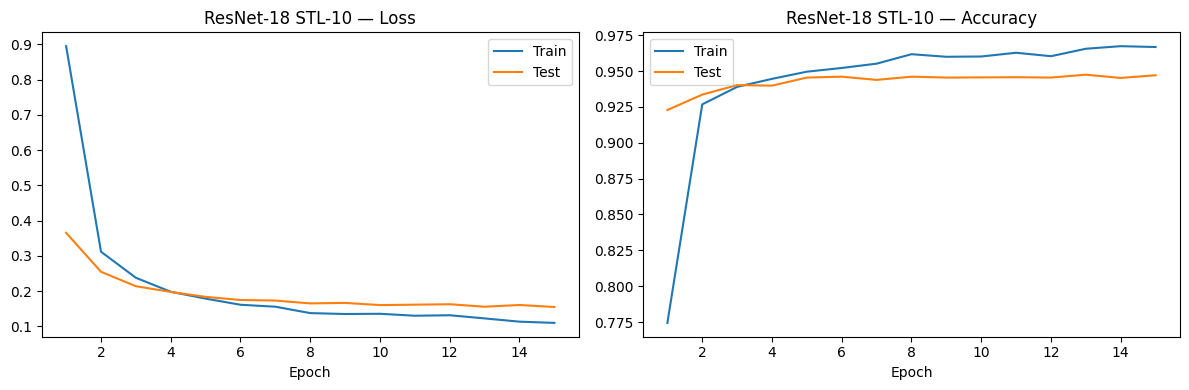

Saved: resnet18_stl10.pth


In [17]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        n          += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss   = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        n          += x.size(0)
    return total_loss / n, correct / n


EPOCHS = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

for ep in range(1, EPOCHS+1):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
    vl, va = evaluate(model, test_loader, criterion)
    scheduler.step()
    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta);  history["val_acc"].append(va)
    print(f"Ep {ep:02d}/{EPOCHS} | Train loss {tl:.4f} acc {ta:.4f} | Test loss {vl:.4f} acc {va:.4f}")

# Final test accuracy
_, test_acc = evaluate(model, test_loader, criterion)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# Plot curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, EPOCHS+1)
ax1.plot(ep, history["train_loss"], label="Train"); ax1.plot(ep, history["val_loss"], label="Test")
ax1.set_title("ResNet-18 STL-10 — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(ep, history["train_acc"],  label="Train"); ax2.plot(ep, history["val_acc"],  label="Test")
ax2.set_title("ResNet-18 STL-10 — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout(); plt.show()

torch.save(model.state_dict(), "resnet18_stl10.pth")
print("Saved: resnet18_stl10.pth")

In [18]:
# Unfreeze layer4 only so GradCAM can compute gradients
for param in model.layer4.parameters():
    param.requires_grad = True

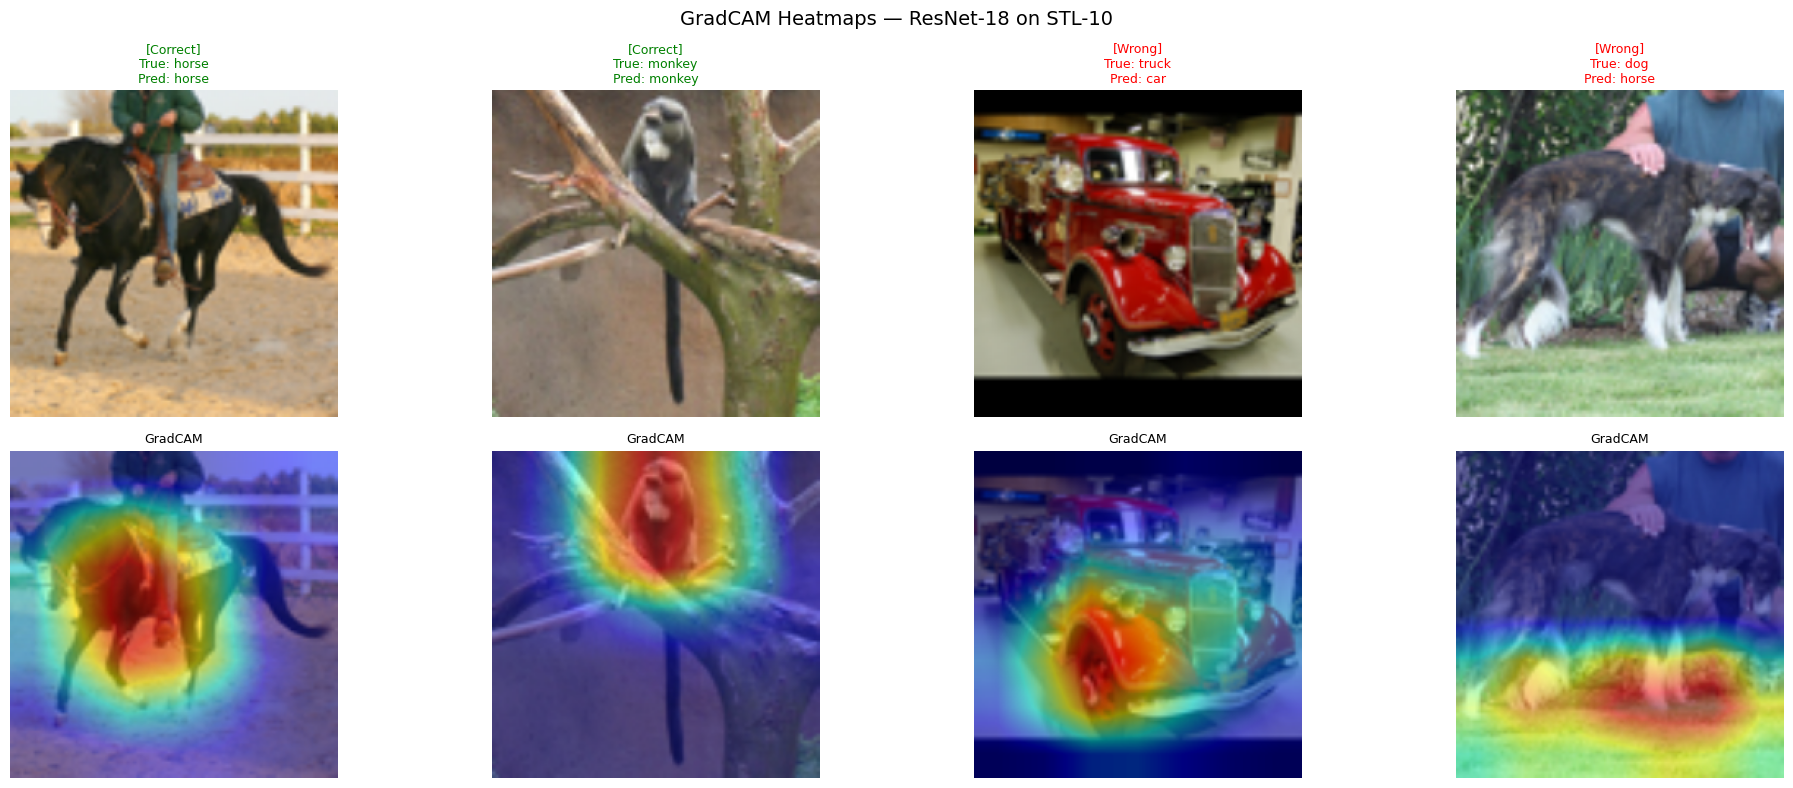

Saved: gradcam_results.png


In [19]:
# GradCAM target layer = last conv layer of ResNet-18
target_layer = [model.layer4[-1]]

# De-normalise helper (for display)
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm(t):
    """Tensor (3,H,W) → numpy (H,W,3) in [0,1]"""
    return (t * STD + MEAN).clamp(0, 1).permute(1,2,0).numpy()


# ── Collect 2 correct + 2 incorrect predictions from test set ──
model.eval()
correct_samples, wrong_samples = [], []

for x, y in test_loader:
    x, y = x.to(DEVICE), y.to(DEVICE)
    with torch.no_grad():
        preds = model(x).argmax(1)
    for i in range(len(y)):
        img, label, pred = x[i], y[i].item(), preds[i].item()
        if pred == label and len(correct_samples) < 2:
            correct_samples.append((img.cpu(), label, pred))
        if pred != label and len(wrong_samples) < 2:
            wrong_samples.append((img.cpu(), label, pred))
    if len(correct_samples) == 2 and len(wrong_samples) == 2:
        break

all_samples = correct_samples + wrong_samples
titles      = ["Correct", "Correct", "Wrong", "Wrong"]

# ── Generate and plot GradCAM heatmaps ──
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("GradCAM Heatmaps — ResNet-18 on STL-10", fontsize=14)

with GradCAM(model=model, target_layers=target_layer) as cam:
    for col, (img_t, label, pred) in enumerate(all_samples):
        inp      = img_t.unsqueeze(0).to(DEVICE)
        rgb      = denorm(img_t)                          # original image
        targets  = [ClassifierOutputTarget(pred)]
        grayscale_cam = cam(input_tensor=inp, targets=targets)[0]
        heatmap  = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

        # Top row: original image
        axes[0, col].imshow(rgb)
        axes[0, col].set_title(
            f"[{titles[col]}]\nTrue: {STL10_CLASSES[label]}\nPred: {STL10_CLASSES[pred]}",
            fontsize=9, color="green" if label==pred else "red"
        )
        axes[0, col].axis("off")

        # Bottom row: GradCAM overlay
        axes[1, col].imshow(heatmap)
        axes[1, col].set_title("GradCAM", fontsize=9)
        axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("gradcam_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gradcam_results.png")